In [1]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using ReactionMechanismSimulator

  Activating project at `~/miniforge3/envs/rmg_env3/julia_env`
Precompiling Precompiling packages...
packages...
   1620.7 ms  ? DomainSets
   1620.7 ms  ? DomainSets
   2481.5 ms  ? Symbolics
   2481.5 ms  ? Symbolics
   5886.3 ms  ? ModelingToolkit
   5886.3 ms  ? ModelingToolkit
  23969.9 ms  ? SciMLSensitivity
  23969.9 ms  ? SciMLSensitivity
Info Given ReactionMechanismSimulator was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1975.7 ms  ? ReactionMechanismSimulator
Info Given ReactionMechanismSimulator was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   1975.7 ms  ? ReactionMechanismSimulator
[ Info: Precompiling ReactionMechanismSimulator [c2d78dd2-25c4-5b79-bebc-be6c69dd440f]
[ Info: Precompiling ReactionMecha

In [2]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK

In [3]:
outdict = readinput("/home/danieltori/CO2_RR_RMG/CO2_Reduction_Ag/HER-Data/HER-Pt/rms/chem10.rms")

[16:14:39] WARNING: not removing hydrogen atom without neighbors
[16:14:40] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352


Dict{Any, Any} with 4 entries:
  "Solvents"              => Solvent[Solvent("water", RiedelViscosity{Float64}(…
  Set(["gas", "surface"]) => Dict{Any, Any}("Reactions"=>ElementaryReaction[pro…
  "gas"                   => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…
  "surface"               => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…

In [4]:
boundarylayerspcs = outdict["gas"]["Species"]
boundarylayerrxns = outdict["gas"]["Reactions"]
surfspcs = outdict["surface"]["Species"]
surfrxns = outdict["surface"]["Reactions"]
interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
solv = outdict["Solvents"][1];

In [5]:
sitedensity = 2.483e-5; # Pt111 site density is 2.483e-9 mol/cm^2 or 2.483e-5 mol/m^2
boundarylayer = IdealDiluteSolution(boundarylayerspcs,boundarylayerrxns,solv,name="boundarylayeruid",diffusionlimited=true);
surf = IdealSurface(surfspcs,surfrxns,sitedensity,name="surface");

In [6]:
# Reservoir is a 100 mL (100e-6 m^3) cell
# Proton concentration is 10^-7 mol/L (10^-4 mol/m^3)
# CO2 concentration is 0.01 mol/L (10 mol/m^3), saturation solubility ~0.03 mol/L
# AVratio in experiments is 36 m^-1 but is measured by surface area/reservoir volume
# Area of the electrode is therefore 3.6e1 m^-1 * 1e2 * 1e-6 m^3 = 3.6e-3 m^2 = 36 cm^2
# Assume boundary layer thickness d_bl = 1 mm or 1e-3 m
# Volume of the boundary layer V_bl = 3.6e-3 m^2 * 1e-3 m = 3.6e-6 m^3
# Actual AVratio is therefore 3.6e-3 m^2 / 3.6e-6 m^3 = 1e3 m^-1 (reciprocal of d_bl)
# Amount of sites is 2.943e-5 mol/m^2 * 3.6e-3 m^2 = 10.595e-8 mol

# For earlier simulations, a 100x linear scale factor is applied,
# so volume becomes 100e-6 m^3 * (1e2)^3 = 100 m^3,
# electrode area becomes 3.6e-3 * (1e2) ^2 = 3.6e1 m^2,
# AVratio becomes 3.6e1 m^2 / 1e2 m^3 = 0.36 m^-1
# Volume of the boundary layer becomes 3.6e1 m^2 * 1e-3 m = 3.6e-2 m^3

pH = 1;
C_proton = 10.0^-pH*1e3; # convert from mol/L to mol/m^3
#C_proton = 0.1*1e3;
#C_co2 = 1e-2*1e3;
#C_default = 1e-12;
C_H2_initial = 1e-12
V_res = 1e3;
layer_thickness = 1e-6;
A_surf = 1e-4 # 1 cm2
#AVratio = 36;
#A_surf = V_res*AVratio;
V_bl = A_surf*layer_thickness;
#V_bl = V_res;
sites = sitedensity*A_surf;

# The initial conditions for individual species are moles not concentration, so we need to multiply concentration by boundary layer volume
initialcondsboundarylayer = Dict(["proton"=>C_proton*V_bl,
                                  #"CO2"=>C_co2*V_bl,
                                  "H2"=>C_H2_initial*V_bl,
                                #   "O=CO"=>C_default*V_bl,
                                  "V"=>V_bl,"T"=>298,"Phi"=>0.0,"d"=>0.0]);
initialcondsreservoir = Dict(["proton"=>C_proton,
                              "H2" => C_H2_initial,
                              #"CO2"=>C_co2,
                              "V"=>V_res,"T"=>298]);


# Assume voltage is -1.0 V vs. R.H.E. which equates to -1.414 V vs. S.H.E. at pH=7
initialcondssurf = Dict(["HX"=>0.7778*sites,
        #"CO2X"=>0.4*sites,
        # "CHO2X"=>0.1*sites,
        # "CO2HX"=>0.1*sites,
        # "OX"=>0.1*sites,
        # "OCX"=>0.1*sites,
        "vacantX"=>0.2222*sites,
        # "CH2O2X"=>0.05*sites,
        # "CHOX"=>0.04*sites,
        # "CH2OX"=>0.01*sites,
        "A"=>A_surf,"T"=>298,"Phi"=>0]);

In [7]:
domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(phase=boundarylayer, initialconds=initialcondsboundarylayer);
domaincat,y0cat,pcat = ConstantTAPhiDomain(phase=surf,
    initialconds=initialcondssurf);

In [8]:
# Set proton diffusivity to a higher value than calculated from Stokes Einstein equation
# The values are taken from DOI: 10.1039/C8SC01253A
# Values calculated from MD is 1.015 A^2/ps, experimental values are 0.932 A^2/ps.
# 1 A^2/ps = 1e-8 m^2/s
domainboundarylayer.diffusivity[1] = 0.932e-8

9.32e-9

In [9]:
inter,pinter = ReactiveInternalInterfaceConstantTPhi(domainboundarylayer,
  domaincat,interfacerxns,298.15,A_surf);

In [10]:
# start with 1mm layer thickness
diffusionlayer = ConstantReservoirDiffusion(domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness);

In [11]:
interfaces = [inter, diffusionlayer];

In [12]:
@time react,y0,p = Reactor((domainboundarylayer,domaincat), (y0boundarylayer,y0cat), (0.0, 1e4), interfaces, (pboundarylayer,pcat,pinter));

  6.597283 seconds (17.95 M allocations: 1.149 GiB, 8.71% gc time, 99.88% compilation time: <1% of which was recompilation)


In [13]:
@time sol = solve(react.ode,Sundials.CVODE_BDF(),abstol=1e-22,reltol=1e-8);
println(sol.t[end]);
println(sol.retcode);

  3.457088 seconds (4.81 M allocations: 278.471 MiB, 16.81% gc time, 99.87% compilation time)
10000.0
Success


In [14]:
ssys = SystemSimulation(sol,(domainboundarylayer,domaincat,), interfaces,p);

In [15]:
"""
diffusive flux to the reservoir
"""
function flux_to_reservoir(sim,t,reservoirinterface)
    cs = concentrations(sim,t)
    return reservoirinterface.A .* sim.domain.diffusivity .* (cs - reservoirinterface.c) / reservoirinterface.layer_thickness
end

"""
Integrates the flux to the reservoir and computes the concentration assuming
there is no prior concentration of that species in the reservoir
"""
function get_reservoir_concentration(sim,t,reservoirinterface,Vres,C0)
    intg,err = quadgk(x -> flux_to_reservoir(sim,x,reservoirinterface), 0, t);
    #intg[5] = 0;
    #intg[6] = 0;
    return C0 + intg./Vres
end

get_reservoir_concentration

In [16]:
# Logarithmic time scale
t_vals = 10 .^ range(-12, stop=3, length=160);

# Compute reservoir concentrations
flux_vals = [flux_to_reservoir(ssys.sims[1], t, diffusionlayer) for t in t_vals]

conc_vals_bl = [concentrations(ssys.sims[1], t) for t in t_vals]
flux_matrix = hcat(flux_vals...);
conc_matrix_bl = hcat(conc_vals_bl...);


In [17]:
conc_0 = concentrations(ssys.sims[1], 0)
t_vals_2 = 10 .^ range(-9, stop=3, length=130);
conc_vals = [get_reservoir_concentration(ssys.sims[1], t, diffusionlayer, V_res, conc_0) for t in t_vals_2]
conc_matrix = hcat(conc_vals...);

In [18]:
function plotC_Reservoir(sim, cs, tvals, tol, exclude)
    clf()
    xs = cs
    maxes = maximum(xs, dims=2)
    time_filtered = tvals
    xs_filtered = xs
    
    # HER-only species and colors
    species_order = ["proton", "H2"]
    color_map = Dict("proton" => "red", "H2" => "green")
    
    # Build a map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    
    # Plot each species
    for species_name in species_order
        if species_name in exclude
            continue
        end
        
        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]
            
            # Always plot proton and H2, or if above tolerance
            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "H2")
                plot_color = color_map[species_name]
                plot(time_filtered, xs_filtered[i, :]/1000, label=species_name, color=plot_color)
            end
        end
    end
    
    xlabel("Time (s)", fontsize=14)
    ylabel("Bulk Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", fontsize=12)
    xscale("log")
    yscale("log")
end

plotC_Reservoir (generic function with 1 method)

In [19]:
#function plotC_Reservoir(sim, cs, tvals, tol, exclude)
 #   clf()
  #  xs = cs
   # maxes = maximum(xs, dims=2)

   # time_filtered = tvals
   # xs_filtered = xs

    # Custom species order and their corresponding names and color
 #   species_order = ["CO2", "proton", "H2", "O=CO", "C=O", "CO-2", "CCO", "CH4", "OCO", "COC", "COCO", "CC(=O)O", "COC=O"]
 #   color_map = Dict("CO2" => "black", "proton" => "grey", "H2" => "green",
 #                     "O=CO" => "red", "C=O" => "brown", "CO-2" => "blue", "CCO" => "magenta",
 #                     "CH4" => "brown", "OCO" => "orange", "COC" => "teal", "COCO" => "lime", "CC(=O)O" => "teal", "COC=O" => "lime")
    # Replacement map for species labels
   # replacement_map = Dict("CO-2" => "CH3OH", "O=CO" => "HCOOH", "C=O" => "HCHO",
    #                        "CCO" => "C2H5OH", "OCO" => "CH2(OH)2", "COC" => "CH3OCH3", "COCO" => "CH3OCH2OH", "CC(=O)O" => "CH3COOH", "COC=O" => "CH3OCHO")

    # Build a map of species names to indices
   # name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    # Keep track of whether the species is plotted, used for later checks
   # plotted = falses(length(sim.domain.phase.species))

    # Plot species from the custom species dictionary
   # for species_name in species_order
       # if species_name in exclude
        #    continue
       # end

      #  if haskey(name_to_index, species_name)
        #    i = name_to_index[species_name]

        #    if (maxes[i] > tol) || (species_name == "proton") || (species_name == "CCO")  # Always plot proton and ethanol
          #      plot_label = get(replacement_map, species_name, species_name)
          #      plot_color = color_map[species_name]

            #    plot(time_filtered, xs_filtered[i, :]/1000, label=plot_label, color=plot_color)
            #    plotted[i] = true  # Mark as plotted
           # end
      #  end
   # end

    # Plot any remaining species that passed tolerance but were not in species_order
   # for i in 1:length(sim.domain.phase.species)
      #  if plotted[i] || sim.domain.phase.species[i].name in exclude
        #    continue
      #  end

      #  if maxes[i] > tol
       #     species_name = sim.domain.phase.species[i].name
        #    plot(time_filtered, xs_filtered[i, :]/1000, label=species_name)  # Default color
       # end
   # end

   # xlabel("Time (s)", fontsize=14)
   # ylabel("Bulk Concentration (mol/L)", fontsize=14)
   # xticks(fontsize=14)
   # yticks(fontsize=14)
   # legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
#end

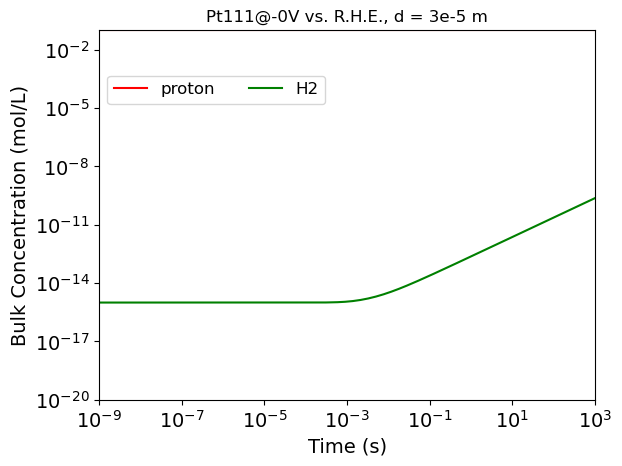

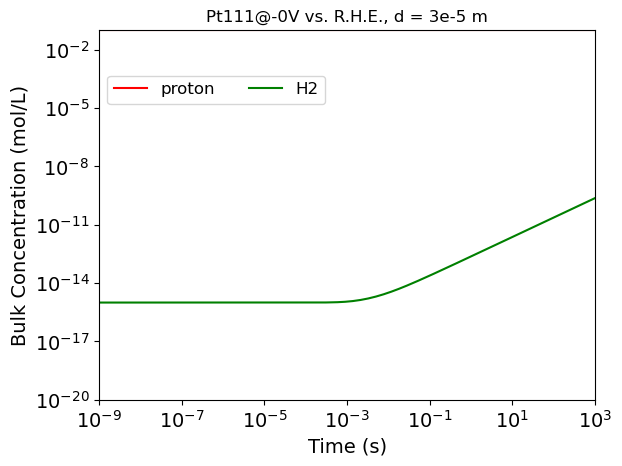

In [20]:
exclude_species = ["H2O"]
plotC_Reservoir(ssys.sims[1], conc_matrix, t_vals_2, 1e-12, exclude_species)

xscale("log")
yscale("log")
xlim(1e-9, 1e3)
ylim(1e-20, 1e-1)
legend(loc="upper left", bbox_to_anchor=(0, 0.9), fontsize=12, ncol=2)
title("Pt111@-0V vs. R.H.E., d = 3e-5 m")
gcf()

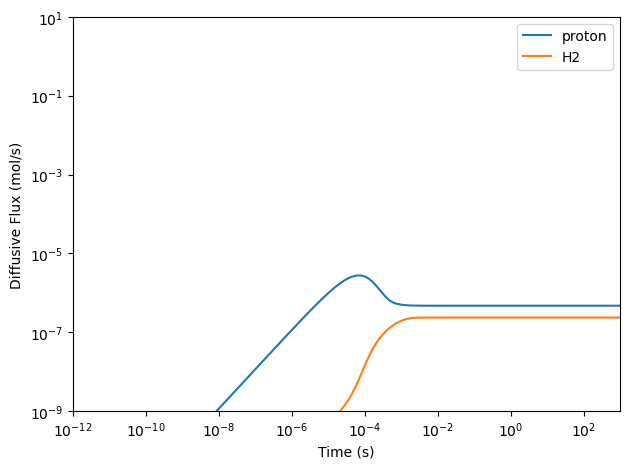

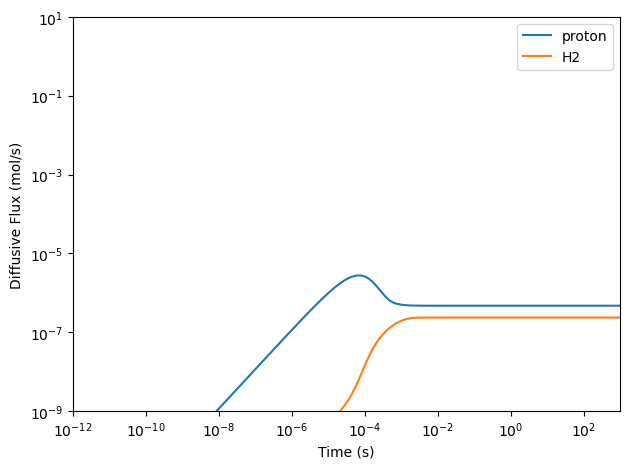

In [21]:
clf()

for i in 1:size(flux_matrix, 1)
    if maximum(abs.(flux_matrix[i, :])) > 1e-10
        plot(t_vals, abs.(flux_matrix[i, :]), label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Diffusive Flux (mol/s)")
xlim(1e-12, 1e3)
ylim(1e-9, 1e1)
legend()
tight_layout()
gcf()

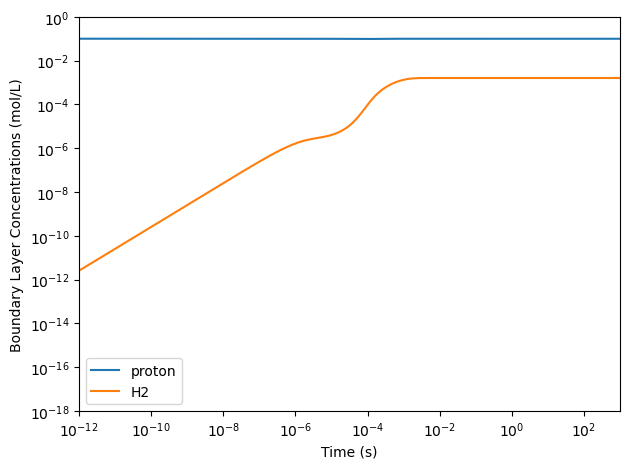

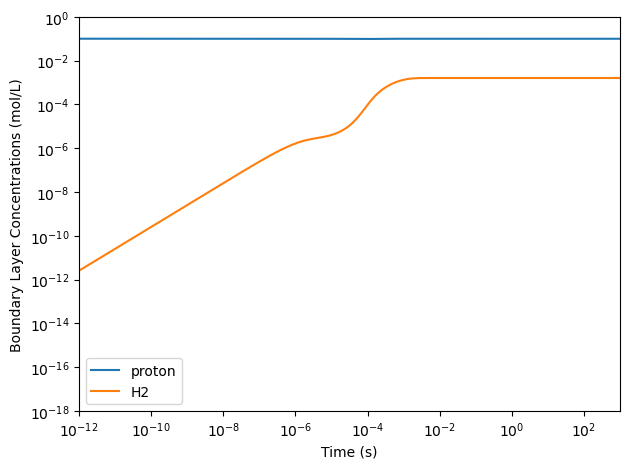

In [22]:
clf()
for i in 1:size(conc_matrix_bl, 1)
    if maximum(conc_matrix_bl[i, :]) > 1e-10
        plot(t_vals, conc_matrix_bl[i, :]/1e3, label=ssys.sims[1].domain.phase.species[i].name)

    end
end

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Boundary Layer Concentrations (mol/L)")
xlim(1e-12, 1e3)
ylim(1e-18, 1)
legend()
tight_layout()
gcf()

In [23]:
# Helper function
function plotX(sim, tol, t_end, exclude)
    clf()
    xs = molefractions(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    for i = 1:length(maxes)
        species_name = sim.domain.phase.species[i].name
        if maxes[i] > tol && !(species_name in exclude)
            plot(time_filtered, xs_filtered[i,:], label=species_name)
        end
    end
    legend()
    xlabel("Time (s)")
    ylabel("Concentration (mol/m^3)")
end

plotX (generic function with 1 method)

In [24]:
function plotC(sim, tol, t_end, exclude)
    clf()
    xs = concentrations(sim)
    maxes = maximum(xs, dims=2)
    
    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]
    
    # HER species only
    species_order = ["proton", "H2"]
    color_map = Dict("proton" => "red", "H2" => "blue")
    
    # Build map of species names to indices
    name_to_index = Dict(sim.domain.phase.species[i].name => i for i in 1:length(sim.domain.phase.species))
    
    # Plot each species
    for species_name in species_order
        if species_name in exclude
            continue
        end
        
        if haskey(name_to_index, species_name)
            i = name_to_index[species_name]
            
            # Always plot proton and H2, or if above tolerance
            if (maxes[i] > tol) || (species_name == "proton") || (species_name == "H2")
                plot_color = color_map[species_name]
                plot(time_filtered, xs_filtered[i, :]/1000, label=species_name, color=plot_color)
            end
        end
    end
    
    xlabel("Time (s)", fontsize=14)
    ylabel("Boundary Layer Concentration (mol/L)", fontsize=14)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(loc="upper left", fontsize=12)
end

plotC (generic function with 1 method)

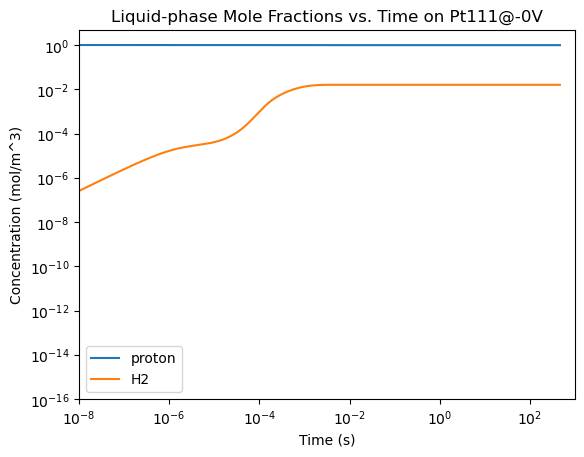

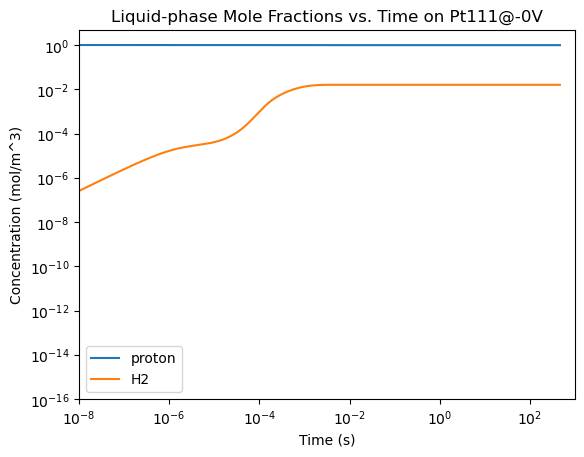

In [25]:
exclude_species = ["H2O"]
plotX(ssys.sims[1], 1e-12, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-8, 1e3)
ylim(1e-16, 5)
title("Liquid-phase Mole Fractions vs. Time on Pt111@-0V")
gcf()

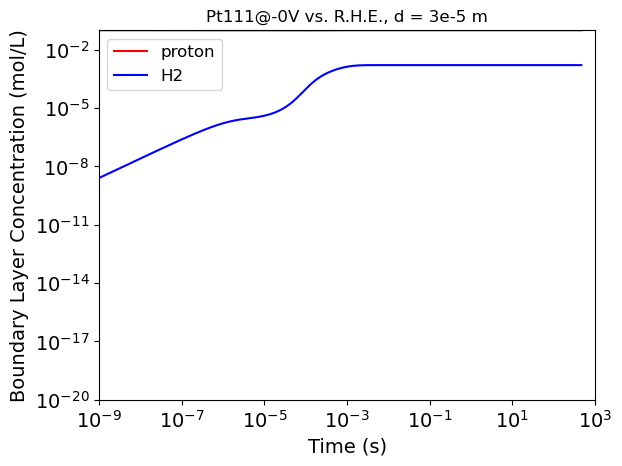

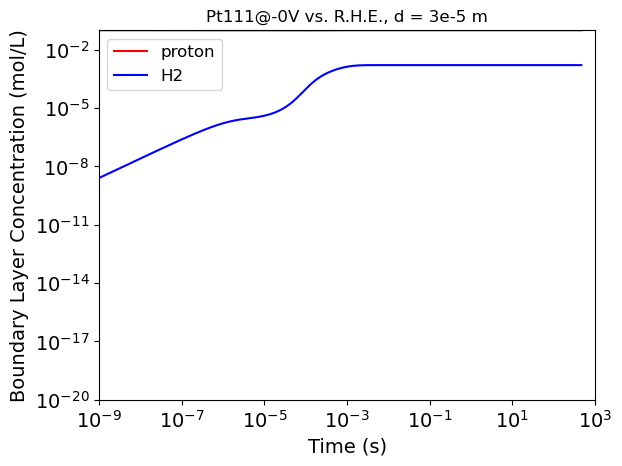

In [26]:
exclude_species = ["H2O"]
plotC(ssys.sims[1], 1e-10, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-9, 1e3)
ylim(1e-20, 1e-1)
title("Pt111@-0V vs. R.H.E., d = 3e-5 m")
gcf()

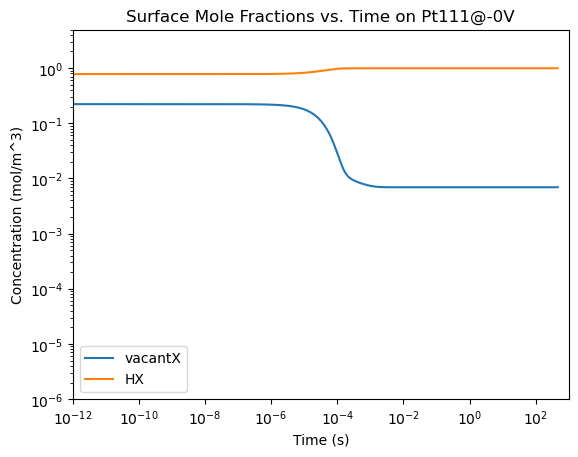

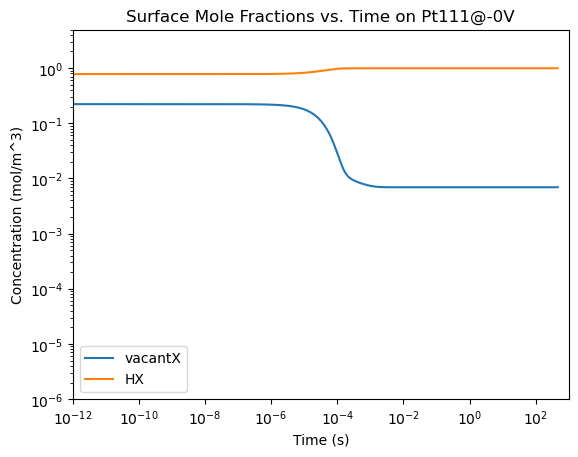

In [27]:
exclude_species = ["H2O"]
plotX(ssys.sims[2], 1e-3, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-6, 5)
title("Surface Mole Fractions vs. Time on Pt111@-0V")
gcf()

In [28]:
#ts = 10.0 .^ range(-10, 3; step=1)
#fd1 = makefluxdiagrams(ssys, ts)

In [29]:
species_list = ["proton", "vacantX", "HX", "H2"];
species_order = ["proton", "vacantX", "HX", "H2"];
color_map = Dict("proton" => "red", "H2" => "blue", "vacantX" => "green", "HX" => "orange");
spc_names = [s.name for s in ssys.species];
G_val = Float64[];
T = 300.0; 

for spc in species_list
    ind = findfirst(==(spc), spc_names);
    if isnothing(ind)
        @warn "Species $spc not found"
        push!(G_val, NaN);
    else
        sp = ssys.species[ind];
        G = getGibbs(sp.thermo, T);
        push!(G_val, G);
    end
end

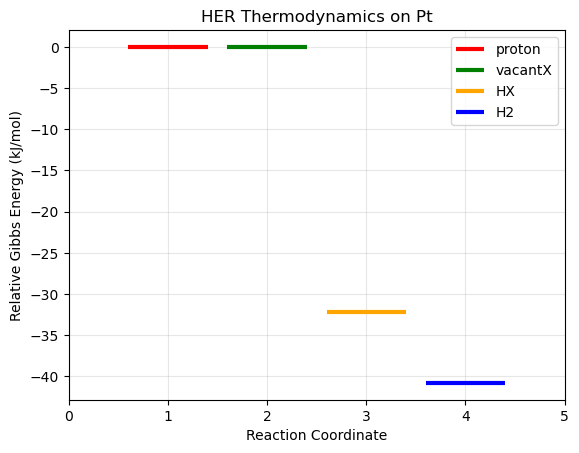

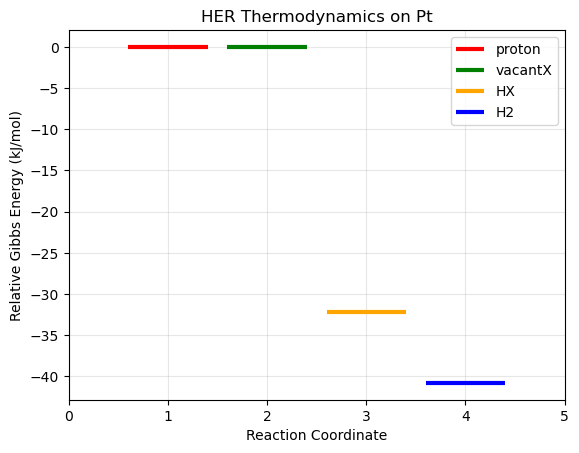

In [30]:
# Calculate relative energies
dG = G_val .- G_val[1];  # Reference to proton

clf()
for (i, name) in enumerate(species_list)
    if !isnan(dG[i])
        species_color = get(color_map, name, "black")
        hlines([dG[i]/1000], xmin=i-0.4, xmax=i+0.4, 
               colors=species_color, linewidth=3, label=name)
    end
end

xlim(0, length(species_list)+1)
xlabel("Reaction Coordinate")
ylabel("Relative Gibbs Energy (kJ/mol)")  # Converted to kJ
legend()
title("HER Thermodynamics on Pt")
grid(true, alpha=0.3)
gcf()

In [31]:
function plotROP(ssys,name,t;N=0,tol=0.01)
    clf()
    rop = rops(ssys, name, t)
    inds = rop.nzind[reverse(sortperm(abs.(rop.nzval)))]
    if N == 0
        N = length(inds)
    elseif N > length(inds)
        N = length(inds)
    end
    inds = inds[1:N]
    mval = abs(rop[inds[1]])
    minval = mval*tol
    k = 1
    while k < length(inds) && abs(rop[inds[k]]) >= minval
        k += 1
    end
    inds = inds[1:k]
    net_rops = sum(rop[inds])
    println("Net ROPs for species $name is: $net_rops")

    for (i, j) in enumerate(inds)
        println("Showing the reaction with $i th highest ROP for species $name:")
        println(getrxnstr(ssys.reactions[j]))
        println("ROP = ", rop[inds[i]])
        println(ssys.reactions[j].kinetics)
    end

    xs = Array{Float64,1}(1:length(inds))
    barh(xs,reverse(rop[inds]))
    yticks(xs,reverse(getrxnstr.(ssys.reactions[inds])))
    xlabel("Production/Loss Rate mol/s")
    gcf()
end

plotROP (generic function with 1 method)

In [32]:
function PrintKinDetail(inter, speciesname)
    println("Showing Kinetics details for reactions involving species $speciesname\n")
    for (i,rxn) in enumerate(inter.reactions)
        flag = false
        for j = 1:length(rxn.reactants)
            if rxn.reactants[j].name == speciesname
                flag = true
            end
        end
        for j = 1:length(rxn.products)
            if rxn.products[j].name == speciesname
                flag = true
            end
        end
        if flag
            println(getrxnstr(rxn))
            println(rxn.kinetics)
            kf = inter.kfs[i]
            krev = inter.krevs[i]
            kc = kf/krev
            println("kf = $kf")
            println("krev = $krev")
            println("Kc = $kc\n")
        end
    end
end

PrintKinDetail (generic function with 1 method)

In [33]:
"""
Integrates the ROP in the boundary layer and computes the concentration
"""
function get_boundary_layer_concentration(sim,t,spc,Vbl,C_0)
    intg,err = quadgk(x -> sum(rops(sim,spc,t)), 0, t);
    return C_0 + intg ./ Vbl;
end

get_boundary_layer_concentration

In [34]:
"""
diffusive flux to the reservoir using concentration from ROP integration
"""
function flux_to_reservoir_2(bsol,t,spc,Vbl,C_0,reservoirinterface)
    cs = get_boundary_layer_concentration(bsol,t,spc,Vbl,C_0)
    spc_idx = findfirst(s -> s.name == spc, bsol.sims[1].species)
    d = bsol.sims[1].domain.diffusivity[spc_idx];
    c_res = reservoirinterface.c[spc_idx];
    return reservoirinterface.A * d * (cs - c_res) / reservoirinterface.layer_thickness
end

flux_to_reservoir_2

In [35]:
# Compute ROP over time
ROP_vals = [sum(rops(ssys, "H2", t)) for t in t_vals];
# Compute boundary layer accumulation by integration
Cbl_vals = [get_boundary_layer_concentration(ssys, t, "H2", V_bl, C_H2_initial) for t in t_vals];
# Compute flux over time using Cbl_vals
F_vals = [flux_to_reservoir_2(ssys, t, "H2", V_bl, C_H2_initial, diffusionlayer) for t in t_vals];

sys:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


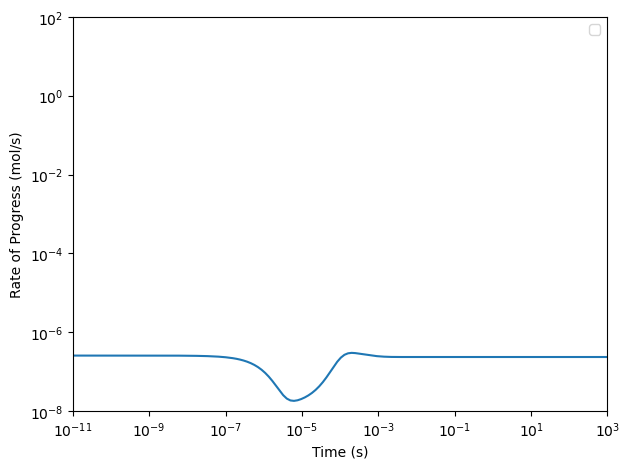

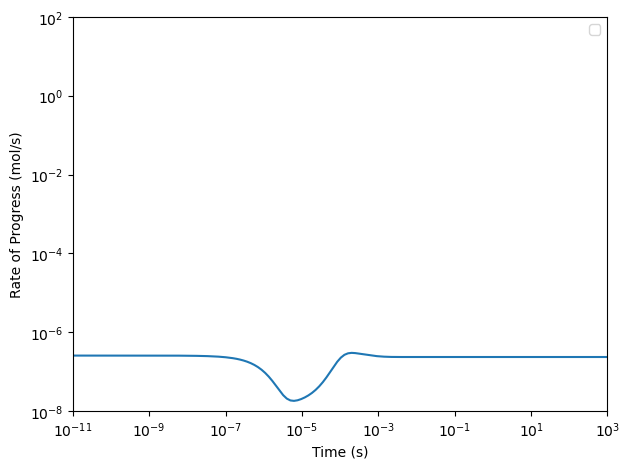

In [36]:
# Plots the ROP of H2
clf()

plot(t_vals, ROP_vals)

xscale("log")
xlim(1e-11,1e3)
yscale("log")
ylim(1e-8,1e2)
xlabel("Time (s)")
ylabel("Rate of Progress (mol/s)")
legend()
tight_layout()
gcf()

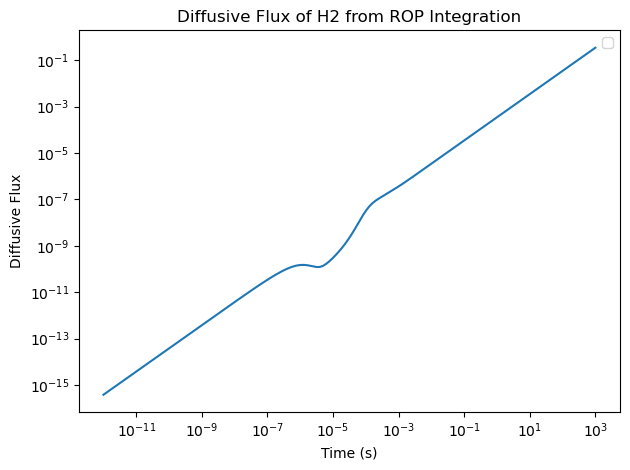

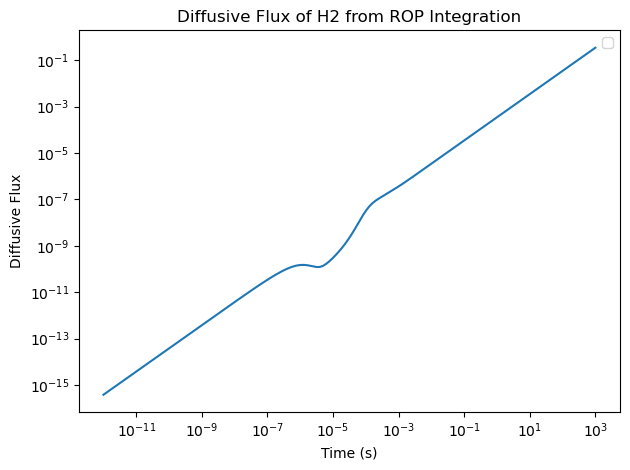

In [37]:
# Plots the Diffusion Flux Into Reservoir Using Integrated Concentration from ROP Analysis
clf()

plot(t_vals, F_vals)

xscale("log")
yscale("log")
xlabel("Time (s)")
ylabel("Diffusive Flux")
title("Diffusive Flux of H2 from ROP Integration")
legend()
tight_layout()
gcf()

Net ROPs for species proton is: -4.712417356151162e-7
Showing the reaction with 1 th highest ROP for species proton:
proton+vacantX<=>HX
ROP = -3.792783481251378e-7
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 63583.615
  q: Float64 0.5
  V0: Float64 0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species proton:
HX+proton<=>H2+vacantX
ROP = -9.19633874899784e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 71495.385
  q: Float64 0.5
  V0: Float64 -0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()

{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 63583.615
  q: Float64 0.5
  V0: Float64 0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest RO

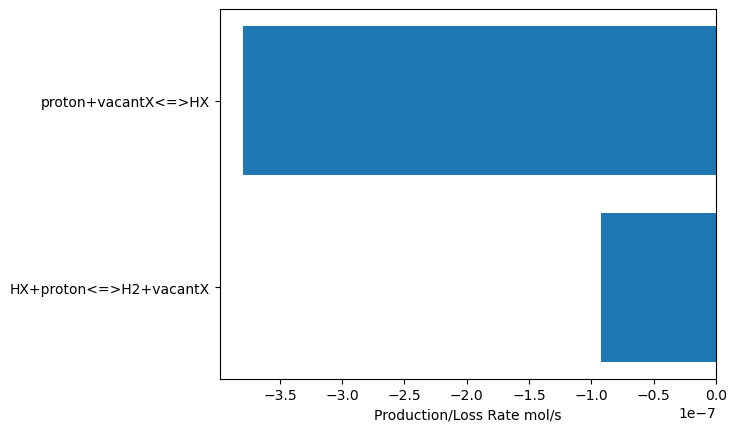

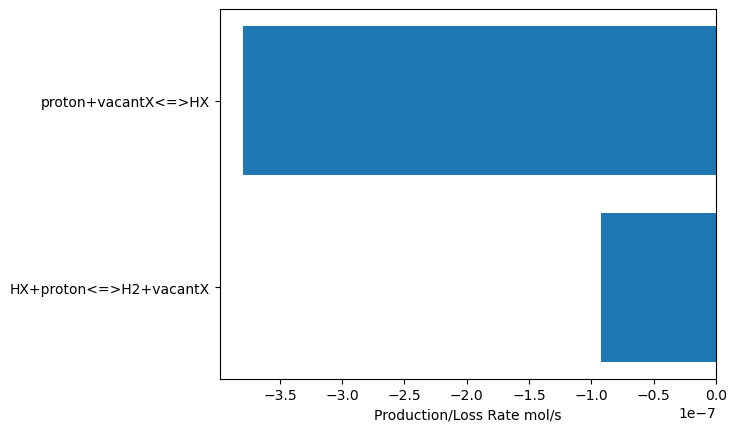

In [38]:
plotROP(ssys, "proton",sol.t[end];N=15,tol=0.0)

Net ROPs for species HX is: 7.940933880509066e-23
Showing the reaction with 1 th highest ROP for species HX:
proton+vacantX<=>HX
ROP = 3.792783481251378e-7
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 63583.615
  q: Float64 0.5
  V0: Float64 0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species HX:
vacantX+vacantX+H2<=>HX+HX
ROP = -2.8731496063515934e-7
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.9114995696964297e9
  n: Float64 0.5000000000006087
  Ea: Float64 -3.797126498285473e-9
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 3 th highest ROP for species HX:
HX+proton<=>H2+vacantX
ROP = -9.19633874899784e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 71495.385
  q: Float64 0.5
  V0: Float64 -0.08

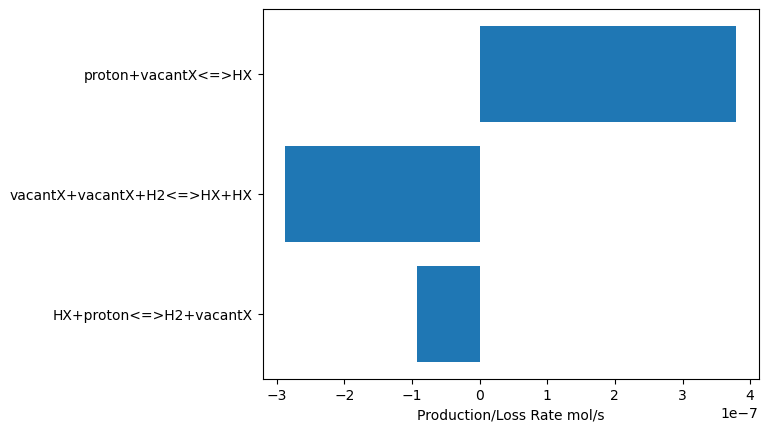

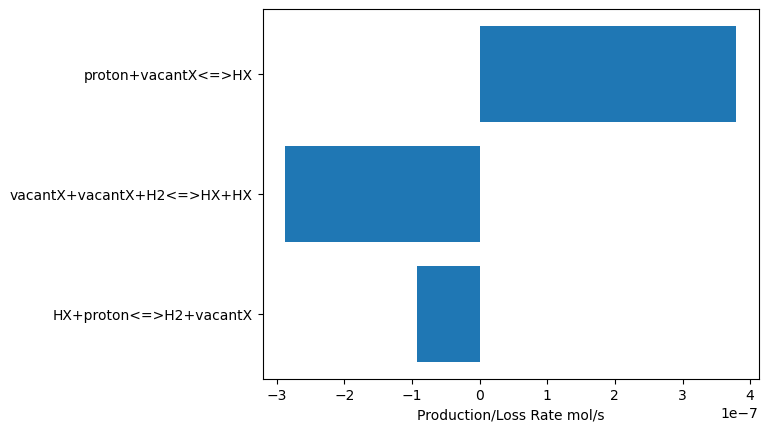

In [39]:
plotROP(ssys, "HX",sol.t[end];N=15,tol=0.0)

Net ROPs for species H2 is: 2.3562086780755807e-7
Showing the reaction with 1 th highest ROP for species H2:
vacantX+vacantX+H2<=>HX+HX
ROP = 1.4365748031757967e-7
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.9114995696964297e9
  n: Float64 0.5000000000006087
  Ea: Float64 -3.797126498285473e-9
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species H2:
HX+proton<=>H2+vacantX
ROP = 9.19633874899784e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 71495.385
  q: Float64 0.5
  V0: Float64 -0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()



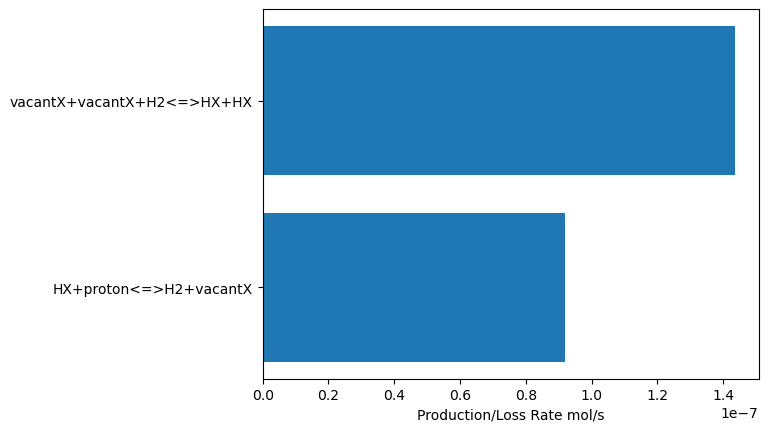

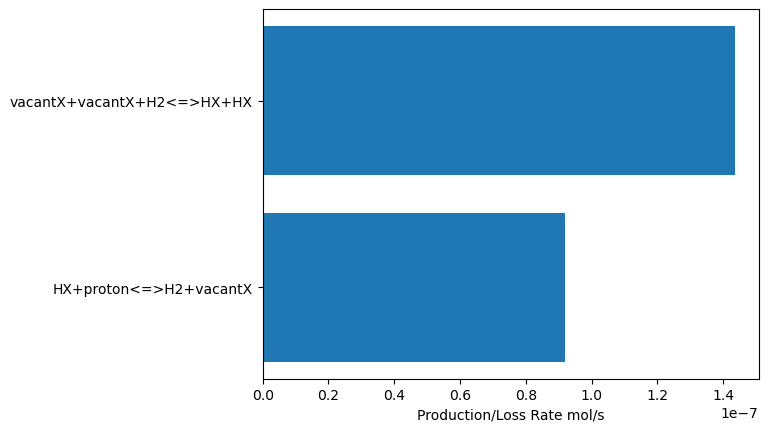

In [40]:
plotROP(ssys, "H2",sol.t[end];N=15,tol=0.0)

In [41]:
fieldnames(typeof(ssys.reactions[1]))

(:index, :reactants, :reactantinds, :products, :productinds, :kinetics, :electronchange, :radicalchange, :reversible, :forwardable, :pairs, :fragmentbasedreactants, :fragmentbasedproducts, :fragmentbasedreactantinds, :fragmentbasedproductinds, :comment)

In [42]:
ssys.reactions[1].kinetics

Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 63583.615
  q: Float64 0.5
  V0: Float64 0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()


In [43]:
inter.kfs

3-element Vector{Float64}:
 221.93145695547398
   0.37488284729378
   3.3005902424818325e10

In [44]:
inter.krevs

3-element Vector{Float64}:
 4.7129719738379934e-5
 0.3150358006163696
 4.9377753841850925e6

In [45]:
rops(ssys, "proton", sol.t[end])

3-element SparseArrays.SparseVector{Float64, Int64} with 2 stored entries:
  [1]  =  -3.79278e-7
  [2]  =  -9.19634e-8

In [46]:
rops(ssys, "H2", sol.t[end])

3-element SparseArrays.SparseVector{Float64, Int64} with 2 stored entries:
  [2]  =  9.19634e-8
  [3]  =  1.43657e-7

In [47]:
function get_current_density(ssys, t, A_surf)
    # H₂ production rate at time t
    H2_rate = sum(rops(ssys, "H2", t))  # mol/s
    
    # Convert to current (2 electrons per H₂)
    current = 2 * 96485 * abs(H2_rate)  # Amperes
    
    # Convert to current density
    j = current / A_surf  # A/m²
    j_mA_cm2 = j * 0.1  # mA/cm²
    
    return j_mA_cm2
end

# Use it at steady state
t_steady = sol.t[end]
j = get_current_density(ssys, t_steady, A_surf)
println("Current density: $(j) mA/cm²")

Current density: 45.46775886082448 mA/cm²


In [48]:
function check_steady_state(ssys, t_end)
    # Check if species concentrations are changing
    dt = t_end / 100  # Small time step
    
    # For boundary layer species
    println("Boundary Layer Species Rates at t = $(t_end):")
    for (i, spc) in enumerate(ssys.sims[1].domain.phase.species)
        rate = sum(rops(ssys.sims[1], spc.name, t_end))
        if abs(rate) > 1e-15
            println("  $(spc.name): $(rate) mol/s")
        end
    end
    
    # For surface species
    println("\nSurface Species Rates:")
    for (i, spc) in enumerate(ssys.sims[2].domain.phase.species)
        rate = sum(rops(ssys.sims[2], spc.name, t_end))
        if abs(rate) > 1e-15
            println("  $(spc.name): $(rate) mol/s")
        end
    end
end

check_steady_state(ssys, sol.t[end])

Boundary Layer Species Rates at t = 10000.0:

Surface Species Rates:


In [49]:
function sweep_HER_potential(Vs_RHE::Vector{Float64}, A_surf)
    log_currents = Float64[]
    global initialcondssurf

    for V in Vs_RHE
        phi = -V  # RMS expects Phi = –V_RHE
        println("Simulating HER at V = $(V) V (Phi = $(phi))")

        # Update Phi
        initialcondssurf["Phi"] = phi

        # Re-initialize domains
        domaincat, y0cat, pcat = ConstantTAPhiDomain(phase=surf, initialconds=initialcondssurf)
        domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(phase=boundarylayer, initialconds=initialcondsboundarylayer)
        inter, pinter = ReactiveInternalInterfaceConstantTPhi(domainboundarylayer, domaincat, interfacerxns, 298.15, A_surf)
        diffusionlayer = ConstantReservoirDiffusion(domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness)
        interfaces = [inter, diffusionlayer]

        # Solve
        react, y0, p = Reactor((domainboundarylayer, domaincat), (y0boundarylayer, y0cat), (0.0, 1e4), interfaces, (pboundarylayer, pcat, pinter))
        sol = solve(react.ode, Sundials.CVODE_BDF(), abstol=1e-22, reltol=1e-8)
        ssys = SystemSimulation(sol, (domainboundarylayer, domaincat), interfaces, p)

        # Compute current
        j = get_current_density(ssys, sol.t[end], A_surf)
        println("  → j = $(round(j, digits=4)) mA/cm²")
        push!(log_currents, log10(j))
    end

    return log_currents
end


sweep_HER_potential (generic function with 1 method)

In [50]:
Vs_RHE = [-0.2, -0.25, -0.3, -0.35, -0.4]
#Vs_RHE = collect(-0.25:0.05:0.25)  # e.g. from –0.25 V to 0.05 V
logj = sweep_HER_potential(Vs_RHE, A_surf)


Simulating HER at V = -0.2 V (Phi = 0.2)
  → j = 3.6281 mA/cm²
Simulating HER at V = -0.25 V (Phi = 0.25)
  → j = 3.6281 mA/cm²
Simulating HER at V = -0.25 V (Phi = 0.25)
  → j = 1.8661 mA/cm²
Simulating HER at V = -0.3 V (Phi = 0.3)
  → j = 0.9344 mA/cm²
Simulating HER at V = -0.35 V (Phi = 0.35)
  → j = 1.8661 mA/cm²
Simulating HER at V = -0.3 V (Phi = 0.3)
  → j = 0.9344 mA/cm²
Simulating HER at V = -0.35 V (Phi = 0.35)
  → j = 0.4307 mA/cm²
Simulating HER at V = -0.4 V (Phi = 0.4)
  → j = 0.1536 mA/cm²
  → j = 0.4307 mA/cm²
Simulating HER at V = -0.4 V (Phi = 0.4)
  → j = 0.1536 mA/cm²


5-element Vector{Float64}:
  0.5596761514961703
  0.27094597085626265
 -0.029470522661411185
 -0.36583129849263885
 -0.8134700470074718

In [51]:
ηs = Vs_RHE  # Signed overpotential (negative for HER)
logj = sweep_HER_potential(Vs_RHE, A_surf)


Simulating HER at V = -0.2 V (Phi = 0.2)
  → j = 3.6281 mA/cm²
Simulating HER at V = -0.25 V (Phi = 0.25)
  → j = 1.8661 mA/cm²
Simulating HER at V = -0.3 V (Phi = 0.3)
  → j = 0.9344 mA/cm²
Simulating HER at V = -0.35 V (Phi = 0.35)
  → j = 0.4307 mA/cm²
Simulating HER at V = -0.4 V (Phi = 0.4)
  → j = 0.1536 mA/cm²


5-element Vector{Float64}:
  0.5596761514961703
  0.27094597085626265
 -0.029470522661411185
 -0.36583129849263885
 -0.8134700470074718

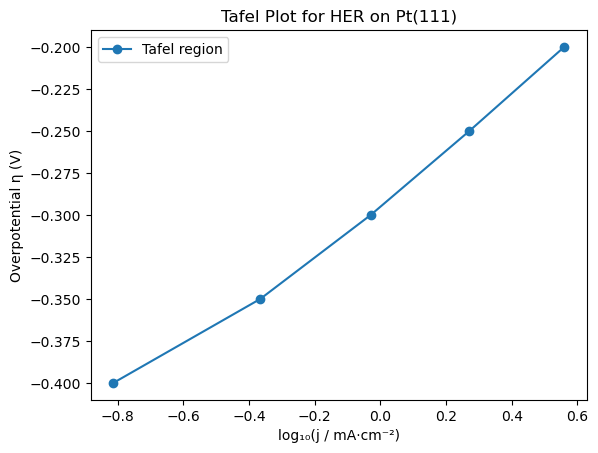

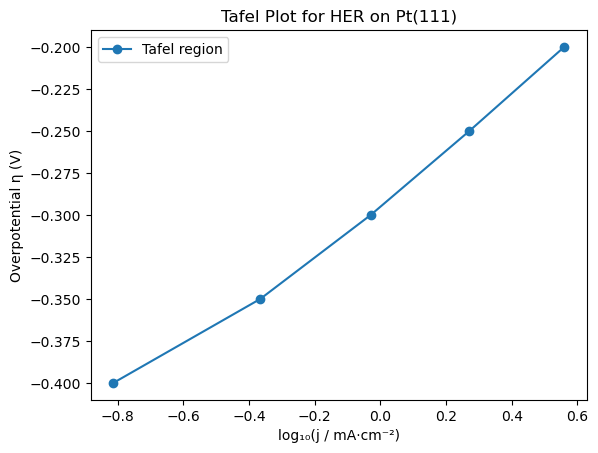

In [52]:
clf()
plot(logj, ηs, "o-", label="Tafel region")
xlabel("log₁₀(j / mA·cm⁻²)")
ylabel("Overpotential η (V)")
title("Tafel Plot for HER on Pt(111)")
legend()
gcf()


In [54]:
function extract_tafel_slope(logj::Vector{Float64}, ηs::Vector{Float64}; fit_range=2:5)
    x = logj[fit_range]
    y = ηs[fit_range]
    p = Polynomials.fit(x, y, 1)  # Linear fit: η = slope·logj + intercept
    tafel_slope = p.coeffs[2]     # coeffs[2] is the slope (coeffs[1] is intercept)
    println("Tafel slope ≈ $(round(tafel_slope * 1000, digits=1)) mV/dec")
    return tafel_slope
end


extract_tafel_slope (generic function with 1 method)

In [55]:
function extract_tafel_slope(logj::Vector{Float64}, ηs::Vector{Float64}; fit_range=3:5)
    x = logj[fit_range]
    y = ηs[fit_range]
    
    # Polynomial fit of degree 1
    p = fit(x, y, 1)  # fit is from Polynomials.jl
    slope = coeffs(p)[2]  # coeffs[2] is the slope
    
    println("Tafel slope ≈ $(round(slope * 1000, digits=1)) mV/dec")
    return slope
end


extract_tafel_slope (generic function with 1 method)

In [56]:
ηs = Vs_RHE  # or abs.(Vs_RHE) if you want unsigned overpotential
extract_tafel_slope(logj, ηs)


Tafel slope ≈ 126.7 mV/dec


0.12670026721982716

Tafel slope ≈ 162.3 mV/dec


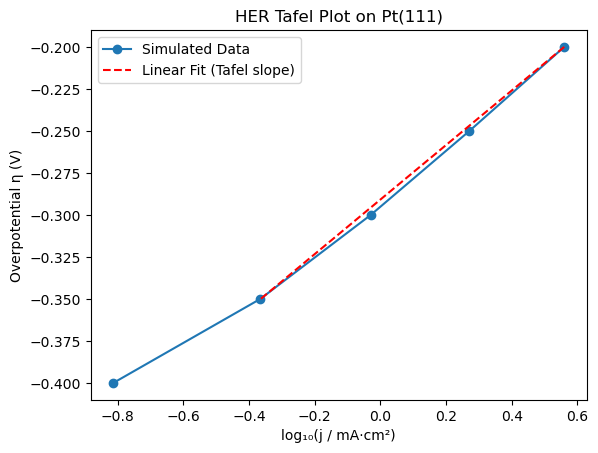

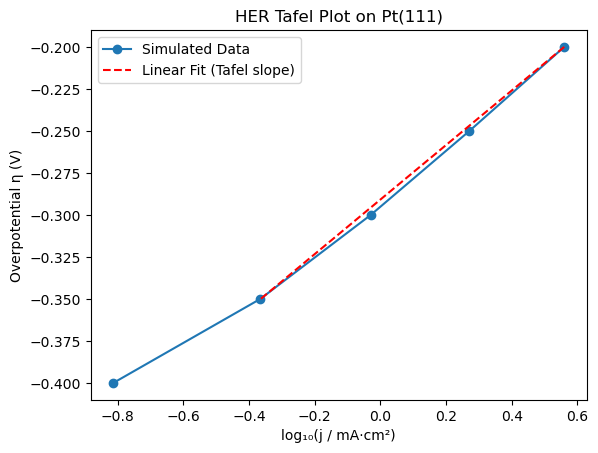

In [63]:
# Get fitted slope
slope = extract_tafel_slope(logj, Vs_RHE, fit_range=1:4)

# Rebuild line manually from fit region (same range used in fitting)
fit_range = 1:4
xfit = logj[fit_range]
yfit = slope .* xfit .+ (Vs_RHE[fit_range][1] - slope * xfit[1])  # match offset

clf()
plot(logj, Vs_RHE, "o-", label="Simulated Data")
plot(xfit, yfit, "--", label="Linear Fit (Tafel slope)", color="red")
xlabel("log₁₀(j / mA·cm²)")
ylabel("Overpotential η (V)")
title("HER Tafel Plot on Pt(111)")
legend()
gcf()


Net ROPs for species H2 is: 2.3562086780755807e-7
Showing the reaction with 1 th highest ROP for species H2:
vacantX+vacantX+H2<=>HX+HX
ROP = 1.4365748031757967e-7
Arrhenius{Float64, Float64, Float64, EmptyRateUncertainty}
  A: Float64 1.9114995696964297e9
  n: Float64 0.5000000000006087
  Ea: Float64 -3.797126498285473e-9
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Showing the reaction with 2 th highest ROP for species H2:
HX+proton<=>H2+vacantX
ROP = 9.19633874899784e-8
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float64 71495.385
  q: Float64 0.5
  V0: Float64 -0.082
  unc: EmptyRateUncertainty EmptyRateUncertainty()

Net ROPs for species HX is: 7.940933880509066e-23
Showing the reaction with 1 th highest ROP for species HX:
proton+vacantX<=>HX
ROP = 3.792783481251378e-7
Arrheniusq{Float64, Float64, Float64, Float64, EmptyRateUncertainty, Float64}
  A: Float64 2.083e10
  n: Float64 1.0
  Ea: Float

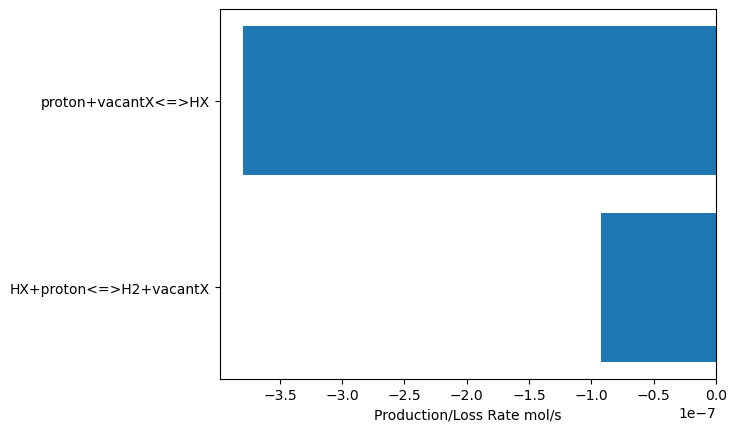

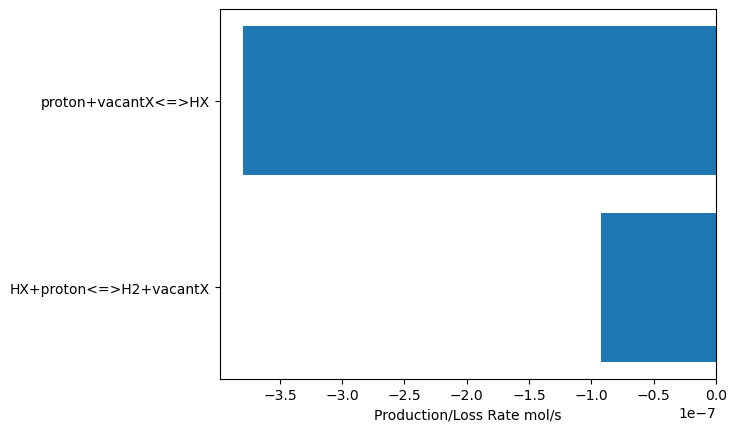

In [58]:
plotROP(ssys, "H2", sol.t[end]; N=10)
plotROP(ssys, "HX", sol.t[end]; N=10)
plotROP(ssys, "proton", sol.t[end]; N=10)


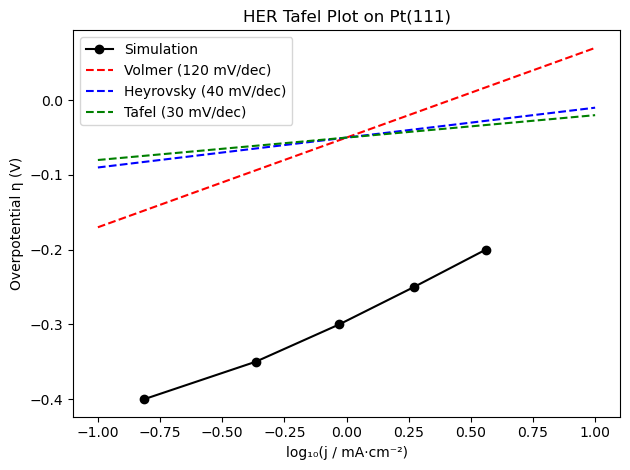

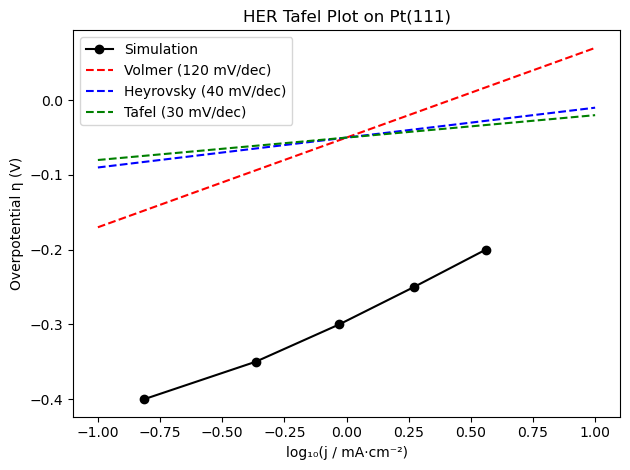

In [59]:
using PythonPlot

#ηs: overpotential (Vs_RHE)
#logj: log10(j / mA/cm²)

clf()
plot(logj, ηs, "o-", label="Simulation", color="black")

# Add guideline lines (e.g., from j = 0.1 to 10 mA/cm² → logj = -1 to 1)
xguide = range(-1, 1, length=100)

# Reference slopes (in V/dec)
s_volmer = 0.120
s_heyrovsky = 0.040
s_tafel = 0.030

# Choose an intercept (e.g., pass through η = -0.05 V at logj = 0)
intercept = -0.05

# Plot reference lines
plot(xguide, s_volmer .* xguide .+ intercept, "--", label="Volmer (120 mV/dec)", color="red")
plot(xguide, s_heyrovsky .* xguide .+ intercept, "--", label="Heyrovsky (40 mV/dec)", color="blue")
plot(xguide, s_tafel .* xguide .+ intercept, "--", label="Tafel (30 mV/dec)", color="green")

xlabel("log₁₀(j / mA·cm⁻²)")
ylabel("Overpotential η (V)")
title("HER Tafel Plot on Pt(111)")
legend()
tight_layout()
gcf()


In [60]:
using PythonPlot
pyplot()

# Your Tafel data
logj = [...]  # Fill in from your sweep
ηs = [...]    # Overpotentials in V (usually -V_RHE)

# Linear fit (use same fit range as before)
fit_range = 1:4
x = logj[fit_range]
y = ηs[fit_range]
p = Polynomials.fit(x, y, 1)
slope = coeffs(p)[2]
intercept = coeffs(p)[1]

xfit = range(minimum(logj), stop=maximum(logj), length=100)
yfit = slope .* xfit .+ intercept

# Reference guideline slopes
xref = range(-1, stop=2, length=100)
y_volmer = 0.120 .* xref .- 0.05
y_heyrovsky = 0.040 .* xref .- 0.05
y_tafel = 0.030 .* xref .- 0.05

clf()
plot(logj, ηs, "ko-", label="Simulation")
plot(xfit, yfit, "r--", label="Fit: $(round(slope*1000, digits=1)) mV/dec")
plot(xref, y_volmer, linestyle="--", color="purple", label="Volmer (120 mV/dec)")
plot(xref, y_heyrovsky, linestyle="--", color="blue", label="Heyrovsky (40 mV/dec)")
plot(xref, y_tafel, linestyle="--", color="green", label="Tafel (30 mV/dec)")

xlabel("log₁₀(j / mA·cm²)", fontsize=12)
ylabel("Overpotential η (V)", fontsize=12)
title("HER Tafel Plot on Pt(111)", fontsize=14)
legend()
grid(true, linestyle="--", linewidth=0.5, alpha=0.7)
tight_layout()
gcf()


LoadError: Python: TypeError: 'module' object is not callable
[0mPython stacktrace:[0m none